In [ ]:
from analyzer import * 
import seaborn as sns 

sns.set_theme(
    style="whitegrid",
    context="paper",
)  

vv = VQAResults()   
test_model = vv.test_model 
human_vqa = vv.human 
model = vv.model 
model.finetuned.unique()   
vqadf, vqapt = vv.finetuning_effect(test_model) 
vqadf = vqadf.melt(id_vars=['model', 'finetuned', 'model_size', 'question_id', 'answer_type', 'question_type'], value_vars=['delta_acc', 'delta_sim'], var_name='score_type', value_name='delta') 
vqadf['dataset'] = 'VQAv2' 
# vqadf.groupby(['model', 'finetuned', 'model_size', 'score_type']).count()
vqa=vqadf.pivot_table(index=['model', 'finetuned', 'model_size'], columns=['answer_type'], values=['delta']).droplevel(0, axis=1) 

model_mg = vv.model_mg
test_model_mg = vv.test_model_mg # get_mg(test_model, filename='5k-test')   
vqq= pd.merge(vv.model, vv.human.groupby(['question_id', 'answer_type', 'question_type']).mean(numeric_only=True).reset_index(), 
                        on=['question_type', 'question_id', 'answer_type'], how='left', suffixes=("_model", "_human")) 
vqq = pd.merge(vqq, model_mg.groupby(['model', 'finetuned', 'question_id'])['MG'].mean(), on=['model', 'finetuned', 'question_id'], how='left') # .head() # , 'question_id', 'answer_type', 'question_type'
vqq["human_correct"] = (vqq["correct_human"] >= 50).astype(int)  
vqq["model_correct"] = (vqq["correct_model"] >= 50).astype(int) 
vqq["cc_quadrant"] = vqq.apply(cc_quadrant, axis=1)  
vqq['dataset'] = 'VQAv2' 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']] 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ss = SpubenchResults()  # pd.read_csv('/home/work/yuna/HPA/evaluation/analysis/old/sputbench.csv') 
df = ss.results 

# df, pv = ss.finetuning_effect(df) 
df['dataset'] = 'Spubench'  
df[df['condition']==''].groupby(['model', 'condition'])['output'].count().reset_index()

In [4]:
from utils.quadrants import get_examples 

for i in [0, 1, -2, -1]: 
    for quad in vqq.cc_quadrant.unique(): 
        ex = get_examples(vqq, i, human_vqa, model, quad)  

        ex["model"].to_csv(
            f"/home/work/yuna/HPA/evaluation/analysis/quadrant_examples/"
            f"{ex['target_group']}_{i}_model.csv"
        )

        ex["human"].to_csv(
            f"/home/work/yuna/HPA/evaluation/analysis/quadrant_examples/"
            f"{ex['target_group']}_{i}_human.csv"
        )

TypeError: get_examples() takes 3 positional arguments but 5 were given

In [3]:
mm = MMStarResults()
dfdf = mm.finetuning_effect(mm.test_model)['row_level'] 
dfdf['dataset'] = 'MMStar'  
dfdf.drop_duplicates(subset=['category', 'model_raw', 'l2_category', 'model', 'family', 'model_size', 'category', 'question_id']).groupby(['model', 'finetuned'])[['correct', 'correct_baseline']].count()
# dfdf.pivot_table(index=['model', 'finetuned'], columns=['dataset'], values=['delta'], aggfunc='count') # , 'category'    
# dfdf.category.unique()
mmstar = dfdf.pivot_table(
    index=['model', 'finetuned'], 
    values='delta', 
    aggfunc='mean'
).reset_index()

mmstar_cat_map = {'coarse perception': "CP", 'fine-grained perception': "FP",
                'instance reasoning': "IR", 'logical reasoning': "LR", 'math': "Math",
                'science & technology': 'S&T'}
dfdf['category'] = dfdf['category'].map(mmstar_cat_map)
mms= pd.merge(mm.model, mm.human.groupby(['question_id', 'l2_category', 'category']).mean(numeric_only=True).reset_index(), 
                on=['question_id', 'l2_category', 'category'], how='left', suffixes=("_model", "_human")) 
mms["human_correct"] = (mms["correct_human"] >= 50).astype(int)  
mms["model_correct"] = (mms["correct_model"] >= 50).astype(int) 
mms["cc_quadrant"] = mms.apply(cc_quadrant, axis=1) 
mms = pd.merge(mm.model_mg, mms, on=['question_id', 'category', 'finetuned', 'model'], how='left')  # .groupby("cc_quadrant")["MG"].agg(['count', 'mean']).to_latex('./tables/appendix/vqa-quadrant.tex', float_format="%.1f")  
mms['dataset'] = "MMStar" 
mms.groupby(['model', "cc_quadrant", 'finetuned'])["MG"].mean().reset_index().head() # 'count',     

/home/work/yuna/HPA/evaluation/analysis/analyzer.py:121: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.human['correct'] = self.human['correct'] * 100


[]


,model,cc_quadrant,finetuned,MG
0,InternVL 3.5 (1B),Human-Only,Pretrained,58.620690
1,InternVL 3.5 (1B),Model-Only,Pretrained,-50.000000
2,InternVL 3.5 (1B),Shared Correct,Pretrained,-36.363636
3,InternVL 3.5 (1B),Shared Wrong,Pretrained,40.268456
4,InternVL 3.5 (2B),Human-Only,Pretrained,57.142857


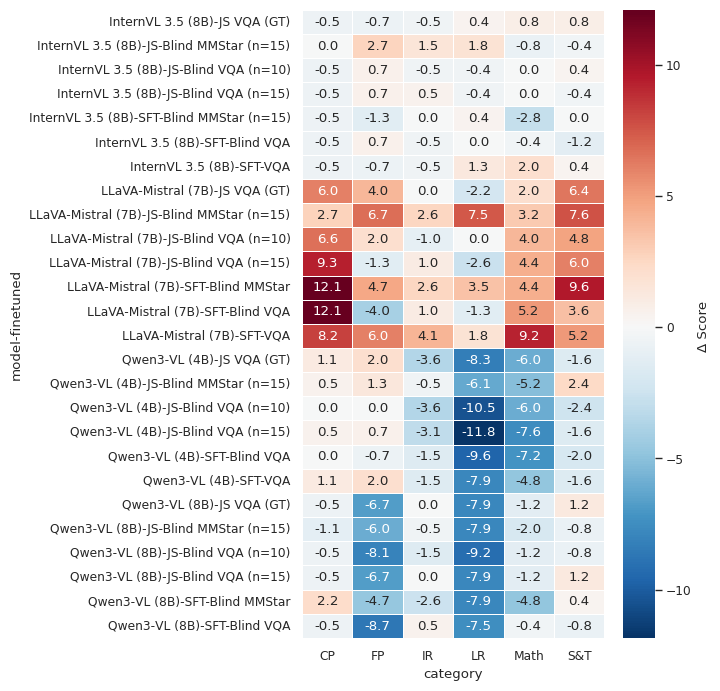

In [5]:
import matplotlib.pyplot as plt 

dfdf.pivot_table(
    index=['model', 'finetuned'], 
    columns='category', 
    values='delta', 
    aggfunc='mean'
).to_csv("./tables/appendix-mmstar-category-heatmap.csv") 

plt.figure(figsize=(7,7))
pt = dfdf.pivot_table(
    index=['model', 'finetuned'], 
    columns='category', 
    values='delta', 
    aggfunc='mean'
)
ax = sns.heatmap(pt, 
    annot=True,
    fmt=".1f",
    cmap="RdBu_r", # 
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Δ Score "}
)
# ax.set_xticklabels(categories, rotation=0)
# ax.set_yticklabels(models, rotation=0)
# plt.title("Blind Training Improves Reasoning-Oriented Categories", pad=10)
plt.tight_layout()
plt.show()

In [6]:
qmg = pd.concat([vqq, mms]).reset_index()
# qmg= qmg[qmg['finetuned'] == "Pretrained"]  
qmg.pivot_table(index=['model', 'cc_quadrant'], columns=['dataset'], values=['MG'], aggfunc=['mean', 'count'])

mean              count        
                                          MG                 MG        
dataset                               MMStar      VQAv2  MMStar   VQAv2
model              cc_quadrant                                         
InternVL 3.5 (1B)  Human-Only      58.620690  78.099048    29.0    35.0
                   Model-Only     -50.000000  -8.697826    58.0    46.0
                   Shared Correct -36.363636  -2.340351    11.0   114.0
                   Shared Wrong    40.268456  63.875047   149.0   179.0
InternVL 3.5 (2B)  Human-Only      57.142857  91.669444    28.0    36.0
                   Model-Only     -34.782609 -10.305455    46.0    55.0
                   Shared Correct -25.000000  -3.246903    12.0   113.0
                   Shared Wrong    48.447205  66.273333   161.0   170.0
InternVL 3.5 (4B)  Human-Only      57.692308  76.195238    26.0    21.0
                   Model-Only     -25.531915  -7.579545    47.0    44.0
                   Shared Correct  -7.142857  -0.781250    14.0   128.0
                   Shared Wrong    61.250000  67.036096   160.0   181.0
InternVL 3.5 (8B)  Human-Only      70.930233  82.568212   172.0   151.0
                   Model-Only     -21.615721  -5.984169   458.0   379.0
                   Shared Correct  -8.783784  -0.898094   148.0   892.0
                   Shared Wrong    62.604341  72.716054  1198.0  1196.0
LLaVA‑1.5 (7B)     Human-Only      23.076923  87.338000    26.0    50.0
                   Model-Only     -45.161290 -10.216129    62.0    62.0
                   Shared Correct -28.571429  -0.674747    14.0    99.0
                   Shared Wrong    31.034483  67.280982   145.0   163.0
LLaVA‑Mistral (7B) Human-Only      49.418605  81.866512   172.0   215.0
                   Model-Only     -45.403900  -5.600772   359.0   518.0
                   Shared Correct -34.459459  -1.774923   148.0   977.0
                   Shared Wrong    34.464148  69.424077  1297.0  1282.0
LLaVA‑Vicuna (7B)  Human-Only      22.580645  87.807317    31.0    41.0
                   Model-Only     -14.285714  -5.778667    56.0    75.0
                   Shared Correct   0.000000   0.614815     9.0   108.0
                   Shared Wrong    21.854305  70.667333   151.0   150.0
Qwen3‑VL (2B)      Human-Only      62.962963  88.895238    27.0    42.0
                   Model-Only     -37.037037  -6.557377    54.0    61.0
                   Shared Correct -23.076923  -2.494393    13.0   107.0
                   Shared Wrong    54.901961  64.838008   153.0   164.0
Qwen3‑VL (4B)      Human-Only      63.694268  88.087565   157.0   193.0
                   Model-Only     -26.246719  -7.701777   381.0   394.0
                   Shared Correct -24.390244  -1.295059   123.0   850.0
                   Shared Wrong    58.801498  72.199859  1068.0  1181.0
Qwen3‑VL (8B)      Human-Only      75.886525  87.594681   141.0   188.0
                   Model-Only     -15.617128  -7.673451   397.0   339.0
                   Shared Correct -12.230216  -0.741988   139.0   855.0
                   Shared Wrong    60.646388  77.725863  1052.0  1236.0
Qwen3 (4B)         Human-Only            NaN        NaN     0.0     NaN
                   Model-Only            NaN        NaN     0.0     NaN
                   Shared Correct        NaN        NaN     0.0     NaN
                   Shared Wrong          NaN        NaN     0.0     NaN
Qwen3 (8B)         Human-Only            NaN        NaN     0.0     NaN
                   Model-Only            NaN        NaN     0.0     NaN
                   Shared Correct        NaN        NaN     0.0     NaN
                   Shared Wrong          NaN        NaN     0.0     NaN

<Axes: xlabel='cc_quadrant', ylabel='MG'>

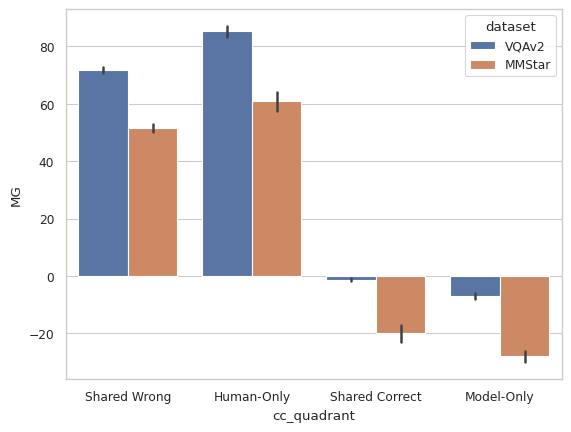

In [7]:
sns.barplot(qmg, x='cc_quadrant', y='MG', hue='dataset') 

In [12]:

pd.merge(mmstar, vqa.reset_index(), on=['model', 'finetuned'], suffixes=(' MMStar', ' VQA')) 

,model,finetuned,delta,model_size,number,other,yes/no
0,InternVL 3.5 (8B),JS VQA (GT),7.608696,8,-0.141385,1.090516,-0.123176
1,InternVL 3.5 (8B),JS-Blind MMStar (n=15),9.299517,8,0.172846,-0.027225,-0.119810
2,InternVL 3.5 (8B),JS-Blind VQA (n=10),7.729469,8,0.090308,0.522691,-0.755010
3,InternVL 3.5 (8B),JS-Blind VQA (n=15),7.850242,8,0.205385,0.398710,-0.820092
4,InternVL 3.5 (8B),SFT-Blind MMStar (n=15),7.487923,8,-0.122231,0.323939,-0.210560
5,InternVL 3.5 (8B),SFT-Blind VQA,7.850242,8,-0.191846,0.481739,-0.657734
6,InternVL 3.5 (8B),SFT-VQA,8.212560,8,-0.186538,1.048149,-0.051259
7,LLaVA‑Mistral (7B),JS VQA (GT),2.633679,7,-0.331923,-1.237583,-0.449383
8,LLaVA‑Mistral (7B),JS-Blind MMStar (n=15),5.107741,7,0.117923,-0.651705,0.034250
9,LLaVA‑Mistral (7B),JS-Blind VQA (n=10),2.793296,7,-0.381154,-2.153369,-0.321480


### Correlations 

In [ ]:
res_HH, res_MM, res_HM  = get_agreements(human_vqa, model_vqa, n_boot=0)  # accuarcy 
corr_mat = get_all_cm(res_HH, res_MM, res_HM )
acc_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='acc_corr') 
plot_unified_agreement_heatmap(corr_mat, res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Accuracy)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-acc.png') 
acc = pd.concat([result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)]) 

res_HH['corr_mat'].mean().reset_index().to_csv('./corr/acc-humans-n6.csv', encoding="utf-8-sig")
res_MM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toM.csv', encoding="utf-8-sig")
res_HM['corr_mat'].mean().reset_index().to_csv('./corr/acc-models-toH-n6.csv', encoding="utf-8-sig")

In [ ]:
res_HH, res_MM, res_HM  =  get_agreements(human_vqa, model_vqa, 'answer_similarity', n_boot=0) 
corr_mat = get_all_cm(res_HH, res_MM, res_HM ) 
sim_corr = res_HM['corr_mat'].mean().sort_values().reset_index(name='sim_corr') 
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
acc = pd.concat([acc, result_to_df(res_HH), result_to_df(res_MM), result_to_df(res_HM)])
plot_unified_agreement_heatmap(corr_mat,  res_HH['corr_mat'].columns, res_MM['corr_mat'].columns, 'Human–Model Agreement (Emb Similarity)', '/home/work/yuna/HPA/evaluation/analysis/figures/agreement-sim.png') 
transform_corr_table(acc) # .to_latex('./tables/appendix/3_spearman-interrater-vqa-finetuned.tex', float_format="%.3f")   

In [ ]:

if isinstance(mg_df.columns, pd.MultiIndex):
    mg_df.columns = ['_'.join(str(c) for c in col if c != '') for col in mg_df.columns.values]

In [ ]:
# from utils.plots import scatterplot, get_family, parse_size 
from utils.plots import scatterplot_finetuned 
import pandas as pd
from utils.corr import corr_by_regime

exclude_models = [
    "LLaVA‑Vicuna‑7B", "Qwen3‑VL‑2B", "LLaVA‑1.5‑7B",
    "InternVL3.5‑1B", "InternVL3.5‑2B", "InternVL3.5‑4B",
]
pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr= pd.merge(pcorr.reset_index(), mg_df.reset_index(), on=['model'])  
pcorr = pcorr[~pcorr['model'].str.contains('MMStar')]
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]

pcorr = pcorr[~pcorr['model'].str.contains('|'.join(exclude_models))]
corr_by_regime(pcorr).to_latex('./tables/appendix/finetuned-pearson-r.tex', float_format="%.1f")    

for fam in pcorr.family.unique(): 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='acc_corr', y_col='MG_Acc', title=f'{fam} accuracy') # 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='sim_corr', y_col='MG_S', title=f'{fam} similairty') # 

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(
    pt,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    # vmin=0, vmax=1,
    linewidths=0.5
)
plt.ylabel("Model")
plt.xlabel("Spurious correlation type")
plt.title("Accuracy by model and spurious correlation type")
plt.tight_layout()
plt.show() # spu-corr-finetune.png

In [ ]:

trainh = human_mc[human_mc['participant_id'].isin(pids)] 
human_mc = human_mc[~human_mc['participant_id'].isin(pids)] 
len(trainh.participant_id.unique()) , len(human_mc.participant_id.unique()) 

In [ ]:

 
df2 = pd.concat([df, meta], axis=1)
pt = (
    df2.groupby(['model', 'trainer', 'supervision', 'dataset'])['delta']
       .mean()
       .unstack(['supervision', 'dataset'])
       .round(3)
) 